# Lab 2: GAN for Images (MNIST)

**Goal:** Build a GAN that generates handwritten digit images from pure noise.

**What you'll learn:**
- How to go from 1 number to 784 pixels (28x28 images)
- Image normalization and why it matters
- Tanh vs Sigmoid — when to use which
- LeakyReLU and why it's better for GANs
- Visualizing generated images across epochs

**Time:** ~60 minutes. Expected compute (whole notebook, approximate): ~10 min on a laptop CPU (these small Linear nets are fast; GPU / Apple-silicon `mps` is similar because data loading dominates). The main training cell (50 epochs) takes ~3–5 min — start it, then read ahead. MNIST (~12 MB) downloads to `./data` on first run.

**How to use this lab:** before each experiment write down a **prediction**, then run and compare with the *Expected* note.

---

## Part 1: Setup and Data Loading

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available()  # Apple-silicon GPU
                      else 'cpu')
print(f"Using device: {device}")

Using device: mps


### Load and explore MNIST

MNIST = 60,000 handwritten digit images, each 28x28 pixels, grayscale.

We normalize to **[-1, 1]** range because our Generator will use **Tanh** (which outputs -1 to 1).

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),              # pixels to [0, 1]
    transforms.Normalize([0.5], [0.5])  # shift to [-1, 1]
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Inspect one batch
images, labels = next(iter(dataloader))
print(f"Batch shape:     {images.shape}")
print(f"One image shape: {images[0].shape}")
print(f"Pixel range:     [{images.min():.1f}, {images.max():.1f}]")
print(f"Labels:          {labels[:10].tolist()}")

100.0%
100.0%
100.0%
100.0%

Batch shape:     torch.Size([64, 1, 28, 28])
One image shape: torch.Size([1, 28, 28])
Pixel range:     [-1.0, 1.0]
Labels:          [1, 2, 8, 5, 2, 6, 9, 9, 9, 4]


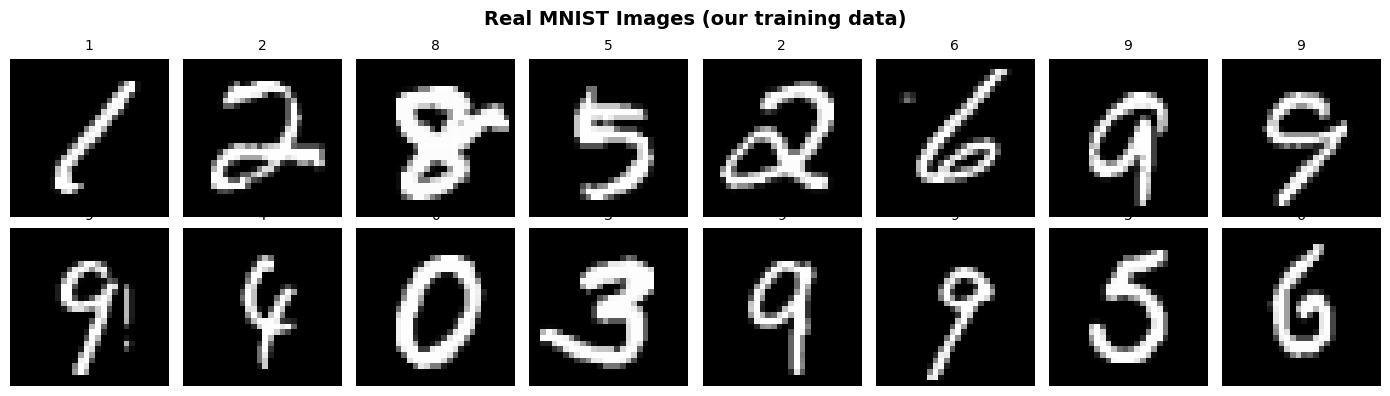

In [4]:
# Visualize some real MNIST images
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i, 0], cmap='gray')
    ax.set_title(f'{labels[i].item()}', fontsize=10)
    ax.axis('off')

plt.suptitle('Real MNIST Images (our training data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Understanding the data shape

```
One image: [1, 28, 28]
             |   |   |
             |   |   +-- width (28 pixels)
             |   +------ height (28 pixels)
             +---------- channels (1 = grayscale)

Flattened:  [784]  (28 * 28 = 784 numbers)
```

Our linear GAN will work with the **flattened** version (784 numbers).

In [5]:
# Show one image as raw pixel values
img = images[0, 0]  # shape: [28, 28]
print(f"Shape: {img.shape}")
print(f"Flattened: {img.view(-1).shape}")
print(f"\nPixel values for row 14 (middle of image):")
print(f"{img[14].numpy().round(2)}")

Shape: torch.Size([28, 28])
Flattened: torch.Size([784])

Pixel values for row 14 (middle of image):
[-1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.   -0.73
  0.84  0.98  0.85 -0.41 -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.
 -1.   -1.   -1.   -1.  ]


---
## Part 2: Build the Generator

The Generator takes a noise vector and transforms it into a 784-pixel image.

```
Noise (64 numbers)  -->  [Linear 256]  -->  [Linear 512]  -->  [Linear 784]  -->  Fake image
                          + ReLU             + ReLU             + Tanh
```

**Key choices:**
- **Tanh** at the output (matches our [-1, 1] data range)
- **ReLU** in hidden layers (standard activation)
- **Noise size = 64** (more noise = more variety in outputs)

In [6]:
NOISE_SIZE = 64
IMAGE_SIZE = 784  # 28 * 28

generator = nn.Sequential(
    nn.Linear(NOISE_SIZE, 256),
    nn.ReLU(),
    nn.Linear(256, 512),
    nn.ReLU(),
    nn.Linear(512, IMAGE_SIZE),
    nn.Tanh()                     # output range: [-1, 1]
).to(device)

print("Generator:")
print(generator)
print(f"\nParameters: {sum(p.numel() for p in generator.parameters()):,}")

Generator:
Sequential(
  (0): Linear(in_features=64, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=512, bias=True)
  (3): ReLU()
  (4): Linear(in_features=512, out_features=784, bias=True)
  (5): Tanh()
)

Parameters: 550,416


Noise shape:  torch.Size([1, 64])
Output shape: torch.Size([1, 784])
Output range: [-0.31, 0.25]


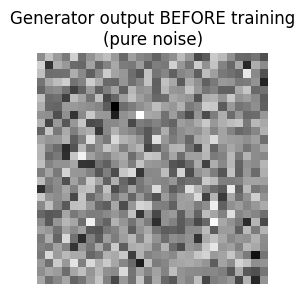

In [8]:
# Test: generate a fake image (before training)
noise = torch.randn(1, NOISE_SIZE, device=device)
fake_image = generator(noise)

print(f"Noise shape:  {noise.shape}")
print(f"Output shape: {fake_image.shape}")
print(f"Output range: [{fake_image.min():.2f}, {fake_image.max():.2f}]")

# Visualize the untrained output
plt.figure(figsize=(3, 3))
plt.imshow(fake_image.detach().cpu().view(28, 28), cmap='gray')
plt.title('Generator output BEFORE training\n(pure noise)')
plt.axis('off')
plt.show()

---
## Part 3: Build the Discriminator

The Discriminator takes a 784-pixel image and outputs a probability: real or fake?

```
Image (784)  -->  [Linear 512]  -->  [Linear 256]  -->  [Linear 1]  -->  Probability
                   + LeakyReLU       + LeakyReLU         + Sigmoid
```

**Key choices:**
- **LeakyReLU** instead of ReLU — lets small gradients flow even for negative values
- **Sigmoid** at output — squash to [0, 1] probability
- Mirror shape of Generator (784 -> 512 -> 256 -> 1)

In [9]:
discriminator = nn.Sequential(
    nn.Linear(IMAGE_SIZE, 512),
    nn.LeakyReLU(0.2),              # lets 20% of negative values through
    nn.Linear(512, 256),
    nn.LeakyReLU(0.2),
    nn.Linear(256, 1),
    nn.Sigmoid()                     # output range: [0, 1]
).to(device)

print("Discriminator:")
print(discriminator)
print(f"\nParameters: {sum(p.numel() for p in discriminator.parameters()):,}")

Discriminator:
Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): LeakyReLU(negative_slope=0.2)
  (2): Linear(in_features=512, out_features=256, bias=True)
  (3): LeakyReLU(negative_slope=0.2)
  (4): Linear(in_features=256, out_features=1, bias=True)
  (5): Sigmoid()
)

Parameters: 533,505


### Why LeakyReLU?

ReLU blocks ALL negative values (gradient = 0). In GANs this can kill learning.

LeakyReLU lets a small fraction through:

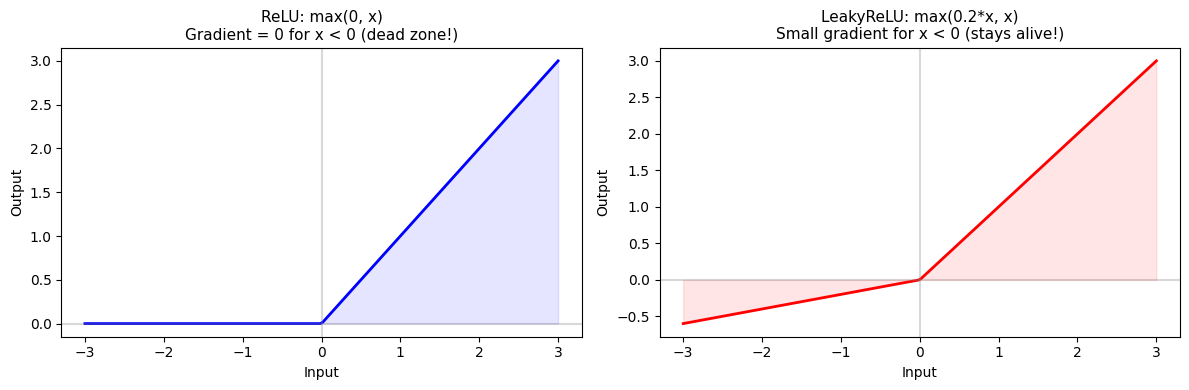

In [10]:
# Visual comparison: ReLU vs LeakyReLU
x = torch.linspace(-3, 3, 200)
relu_out = torch.relu(x)
leaky_out = nn.LeakyReLU(0.2)(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x.numpy(), relu_out.numpy(), 'b-', linewidth=2)
axes[0].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[0].axvline(x=0, color='gray', linestyle='-', alpha=0.3)
axes[0].set_title('ReLU: max(0, x)\nGradient = 0 for x < 0 (dead zone!)', fontsize=11)
axes[0].fill_between(x.numpy(), relu_out.numpy(), alpha=0.1, color='blue')
axes[0].set_xlabel('Input')
axes[0].set_ylabel('Output')

axes[1].plot(x.numpy(), leaky_out.numpy(), 'r-', linewidth=2)
axes[1].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[1].axvline(x=0, color='gray', linestyle='-', alpha=0.3)
axes[1].set_title('LeakyReLU: max(0.2*x, x)\nSmall gradient for x < 0 (stays alive!)', fontsize=11)
axes[1].fill_between(x.numpy(), leaky_out.numpy(), alpha=0.1, color='red')
axes[1].set_xlabel('Input')
axes[1].set_ylabel('Output')

plt.tight_layout()
plt.show()

In [11]:
# Test D on real and fake images
with torch.no_grad():
    real_flat = images[0].view(1, -1).to(device)   # real MNIST image
    fake_flat = fake_image                          # generator output

    print(f"D on real image: {discriminator(real_flat).item():.4f}  (should be close to 1)")
    print(f"D on fake image: {discriminator(fake_flat).item():.4f}  (should be close to 0)")
    print(f"\nBoth around 0.5 -- D hasn't been trained yet.")

D on real image: 0.5252  (should be close to 1)
D on fake image: 0.5033  (should be close to 0)

Both around 0.5 -- D hasn't been trained yet.


---
## Part 4: Loss, Optimizers, and Helper Functions

In [12]:
loss_fn = nn.BCELoss()
gen_opt = torch.optim.Adam(generator.parameters(), lr=0.0002)
dis_opt = torch.optim.Adam(discriminator.parameters(), lr=0.0002)

print("Loss:       BCELoss")
print("Optimizer:  Adam (lr=0.0002)")
print("Batch size: 64")

Loss:       BCELoss
Optimizer:  Adam (lr=0.0002)
Batch size: 64


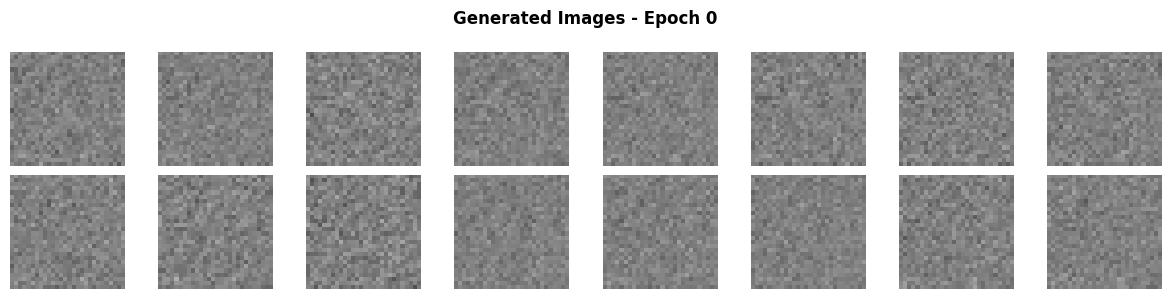

In [13]:
def show_generated_images(generator, epoch, num_images=16, noise_size=NOISE_SIZE, noise=None):
    """Generate and display a grid of images (pass fixed `noise` to watch the SAME samples improve)."""
    generator.eval()
    with torch.no_grad():
        if noise is None:
            noise = torch.randn(num_images, noise_size, device=device)
        num_images = noise.size(0)
        generated = generator(noise).cpu().view(-1, 28, 28)
    generator.train()

    rows = 2
    cols = num_images // rows
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated[i], cmap='gray', vmin=-1, vmax=1)
        ax.axis('off')
    plt.suptitle(f'Generated Images - Epoch {epoch}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Test: show untrained Generator output
show_generated_images(generator, epoch=0)

---
## Part 5: Train the GAN

The training loop is identical to Lab 1, just with:
- **Batches** of images instead of single numbers
- **Flattening** images from 28x28 to 784
- More epochs (images are harder to learn)

**Predict:** at which epoch will you first recognise digits? Will the images be sharp at epoch 50?

Training for 50 epochs...
Dataset: 60000 images
Batches per epoch: 938

Epoch  1/50: D_loss=0.1798  G_loss=5.2968


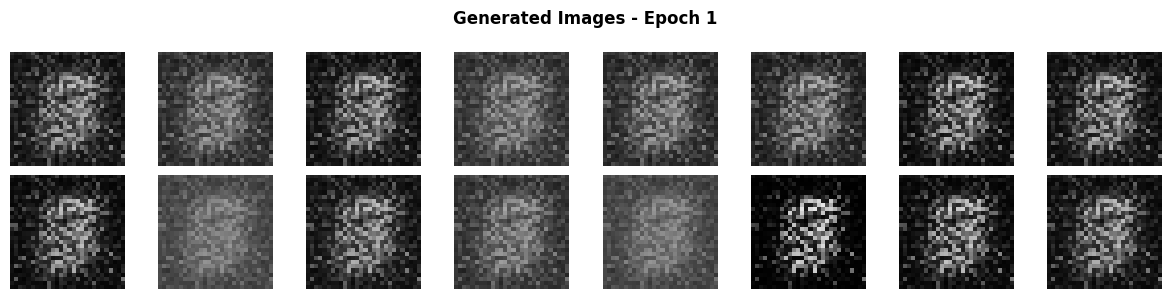


Epoch  5/50: D_loss=0.1494  G_loss=4.6615


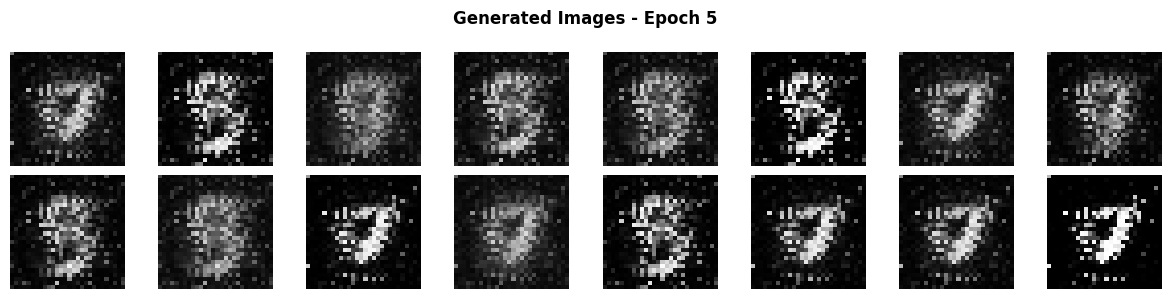


Epoch 10/50: D_loss=0.2654  G_loss=4.9498


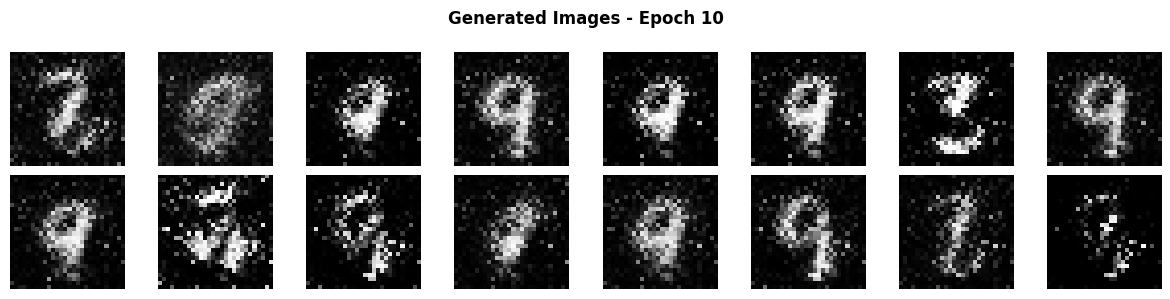


Epoch 20/50: D_loss=0.4304  G_loss=3.3366


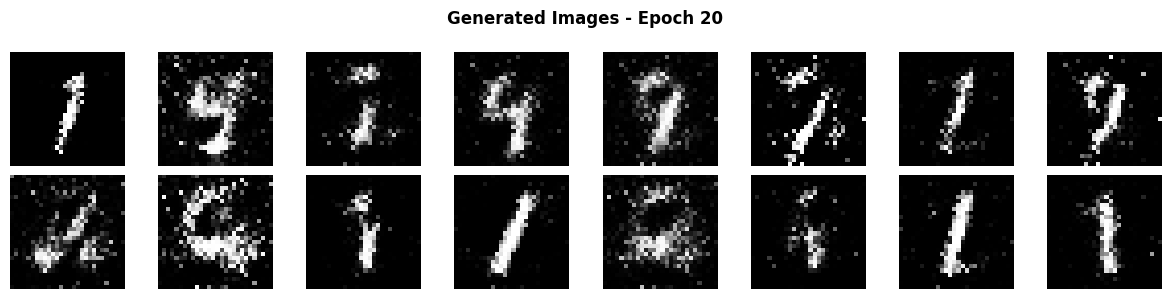


Epoch 30/50: D_loss=0.4724  G_loss=3.3051


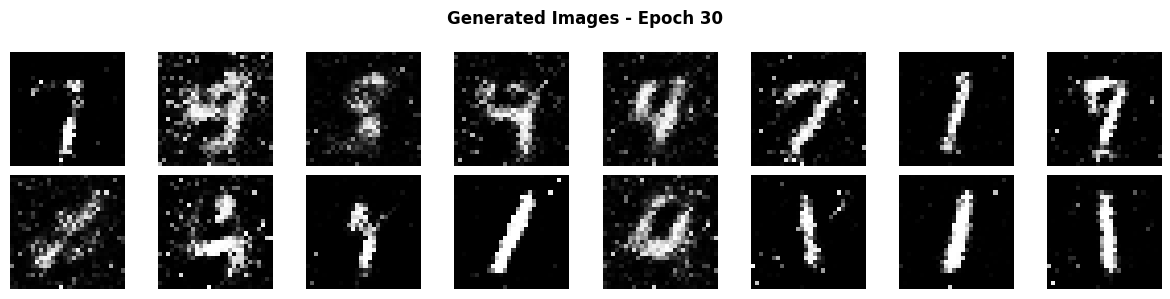


Epoch 40/50: D_loss=0.7254  G_loss=2.0898


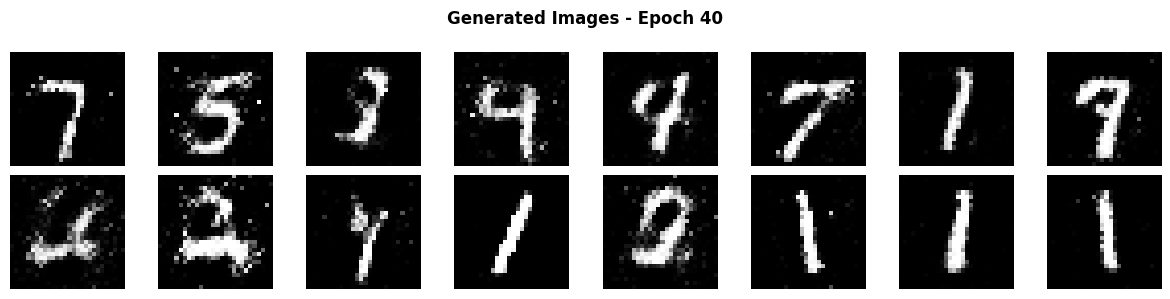


Epoch 50/50: D_loss=0.7763  G_loss=1.9636


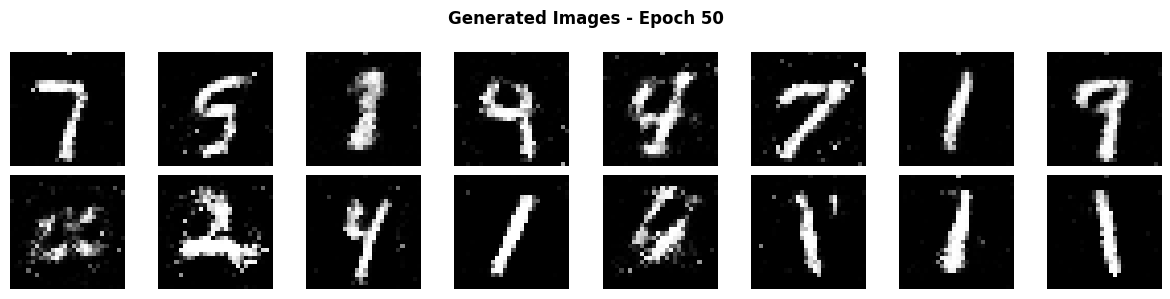


Training complete!


In [14]:
num_epochs = 50
gen_losses = []
dis_losses = []

# Fixed noise for consistent visualization
fixed_noise = torch.randn(16, NOISE_SIZE, device=device)

print(f"Training for {num_epochs} epochs...")
print(f"Dataset: {len(dataset)} images")
print(f"Batches per epoch: {len(dataloader)}")
print("=" * 60)

for epoch in range(1, num_epochs + 1):
    epoch_g_loss = 0
    epoch_d_loss = 0
    num_batches = 0

    for real_images, _ in dataloader:
        batch_size = real_images.size(0)
        real_flat = real_images.view(batch_size, -1).to(device)   # flatten to 784

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # ====== Train Discriminator ======
        # D on real images
        real_pred = discriminator(real_flat)
        loss_real = loss_fn(real_pred, real_labels)

        # D on fake images
        noise = torch.randn(batch_size, NOISE_SIZE, device=device)
        fake_images = generator(noise).detach()
        fake_pred = discriminator(fake_images)
        loss_fake = loss_fn(fake_pred, fake_labels)

        dis_loss = loss_real + loss_fake
        dis_opt.zero_grad()
        dis_loss.backward()
        dis_opt.step()

        # ====== Train Generator ======
        noise = torch.randn(batch_size, NOISE_SIZE, device=device)
        fake_images = generator(noise)
        fake_pred = discriminator(fake_images)
        gen_loss = loss_fn(fake_pred, real_labels)   # G wants D to say "real"

        gen_opt.zero_grad()
        gen_loss.backward()
        gen_opt.step()

        epoch_g_loss += gen_loss.item()
        epoch_d_loss += dis_loss.item()
        num_batches += 1

    # Average losses for the epoch
    avg_g = epoch_g_loss / num_batches
    avg_d = epoch_d_loss / num_batches
    gen_losses.append(avg_g)
    dis_losses.append(avg_d)

    # Print and show images at milestones
    if epoch in [1, 5, 10, 20, 30, 40, 50]:
        print(f"\nEpoch {epoch:2d}/{num_epochs}: D_loss={avg_d:.4f}  G_loss={avg_g:.4f}")
        show_generated_images(generator, epoch, noise=fixed_noise)

print("\nTraining complete!")

---
## Part 6: Analyze the Training

### 6a. Loss curves

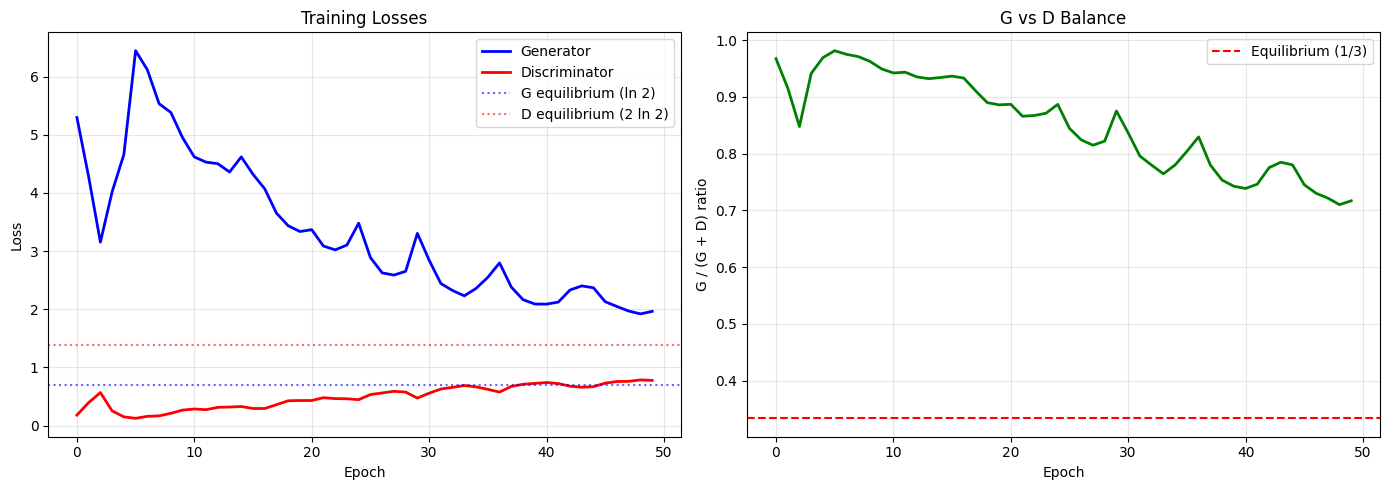

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual losses
axes[0].plot(gen_losses, label='Generator', color='blue', linewidth=2)
axes[0].plot(dis_losses, label='Discriminator', color='red', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].axhline(y=np.log(2), color='blue', linestyle=':', alpha=0.6, label='G equilibrium (ln 2)')
axes[0].axhline(y=2 * np.log(2), color='red', linestyle=':', alpha=0.6, label='D equilibrium (2 ln 2)')
axes[0].set_title('Training Losses')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Balance ratio. At equilibrium D(x)=0.5 everywhere: G_loss = ln 2, D_loss = 2 ln 2 (real + fake term)
# so G / (G + D) = 1/3.
axes[1].plot([g / (g + d + 1e-8) for g, d in zip(gen_losses, dis_losses)],
            color='green', linewidth=2)
axes[1].axhline(y=1/3, color='red', linestyle='--', label='Equilibrium (1/3)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('G / (G + D) ratio')
axes[1].set_title('G vs D Balance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6b. Final generated images — larger grid

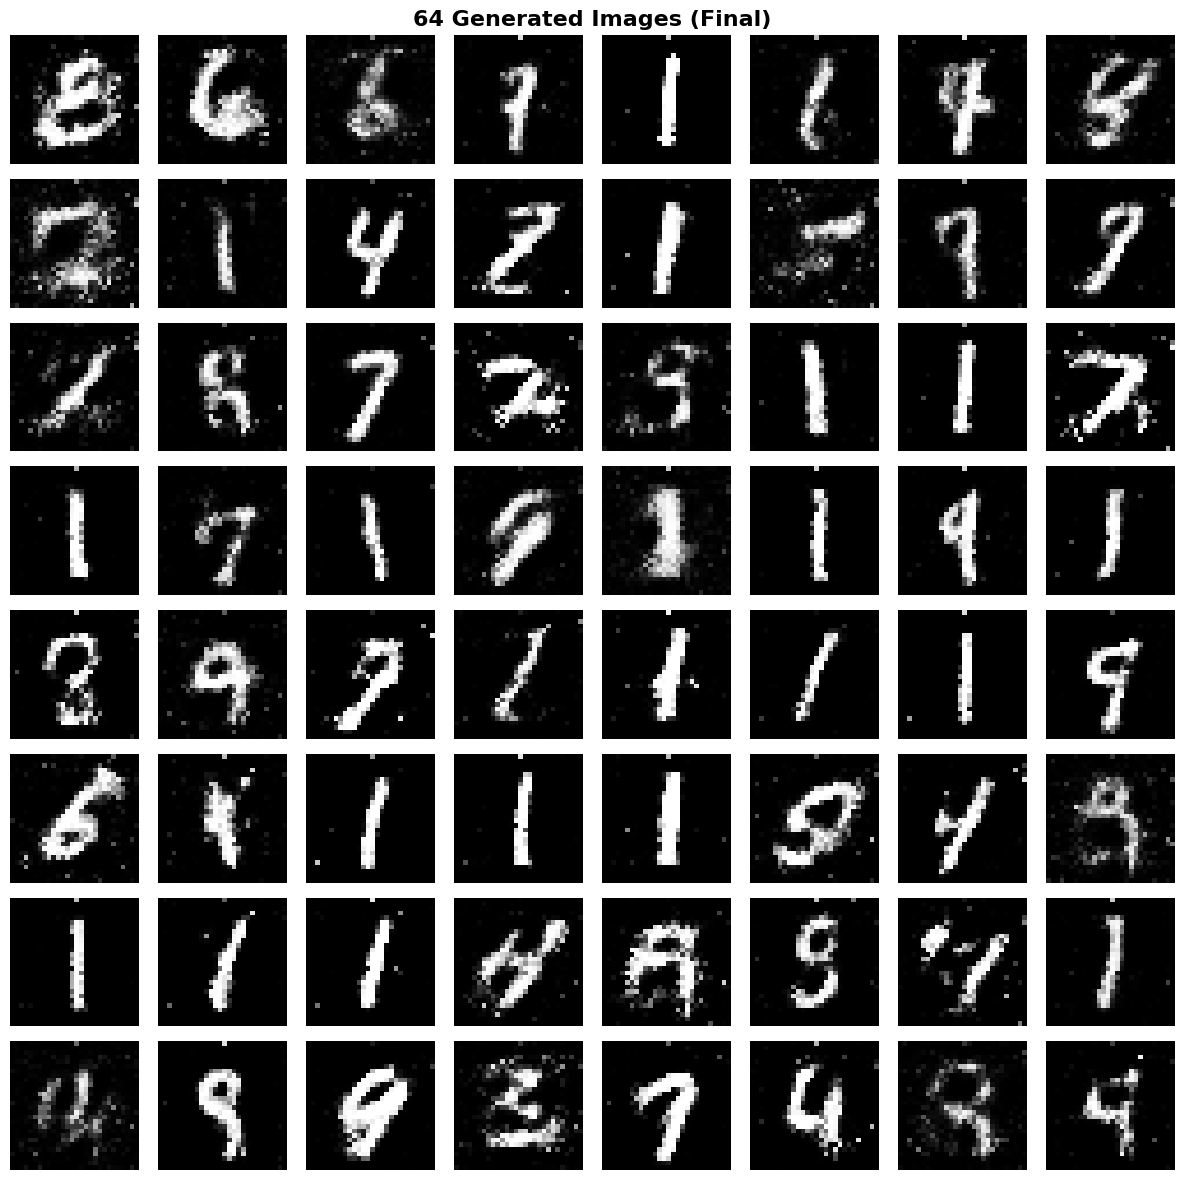

In [16]:
# Generate a big grid of 64 images
generator.eval()
with torch.no_grad():
    noise = torch.randn(64, NOISE_SIZE, device=device)
    generated = generator(noise).cpu().view(-1, 28, 28)

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i], cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')

plt.suptitle('64 Generated Images (Final)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 6c. Real vs Fake — side by side

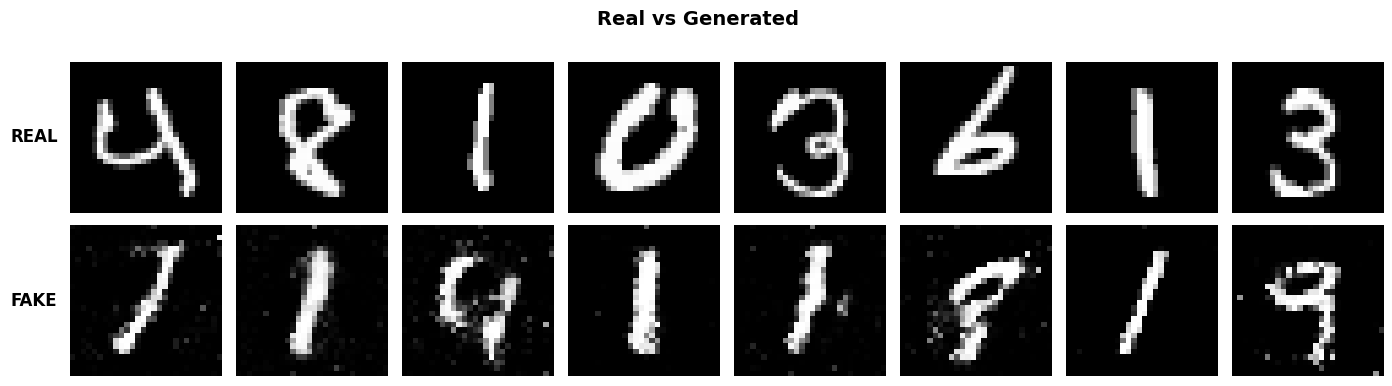

Notice: Generated images are recognizable but BLURRY.
That's because Linear layers have no notion of which pixels are neighbours (no weight sharing).
DCGAN (Lab 3) fixes this with convolutional layers.


In [17]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

# Top row: real images
real_batch = next(iter(dataloader))[0]
for i in range(8):
    axes[0, i].imshow(real_batch[i, 0], cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].text(-0.08, 0.5, 'REAL', transform=axes[0, i].transAxes, ha='right', va='center', fontsize=12, fontweight='bold')

# Bottom row: generated images
with torch.no_grad():
    noise = torch.randn(8, NOISE_SIZE, device=device)
    fakes = generator(noise).cpu().view(-1, 28, 28)
for i in range(8):
    axes[1, i].imshow(fakes[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].text(-0.08, 0.5, 'FAKE', transform=axes[1, i].transAxes, ha='right', va='center', fontsize=12, fontweight='bold')

plt.suptitle('Real vs Generated', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notice: Generated images are recognizable but BLURRY.")
print("That's because Linear layers have no notion of which pixels are neighbours (no weight sharing).")
print("DCGAN (Lab 3) fixes this with convolutional layers.")

---
## Part 7: What the Discriminator Sees

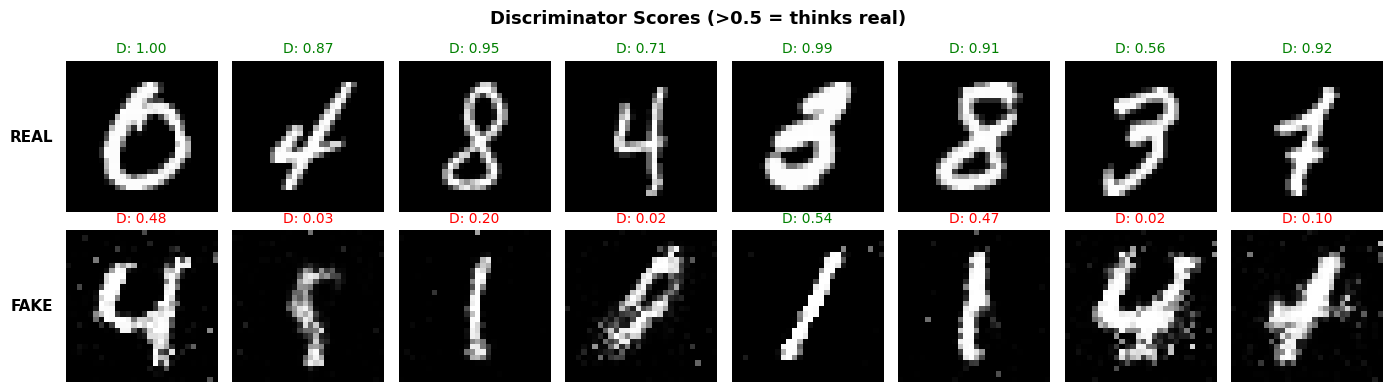

Avg D score on real: 0.8629
Avg D score on fake: 0.2333


In [18]:
# Ask D to judge real and fake images
discriminator.eval()

with torch.no_grad():
    # Real images
    real_batch = next(iter(dataloader))[0][:8]
    real_flat = real_batch.view(8, -1).to(device)
    real_scores = discriminator(real_flat).cpu().squeeze()

    # Fake images
    noise = torch.randn(8, NOISE_SIZE, device=device)
    fake_batch = generator(noise)
    fake_scores = discriminator(fake_batch).cpu().squeeze()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for i in range(8):
    axes[0, i].imshow(real_batch[i, 0], cmap='gray')
    axes[0, i].set_title(f'D: {real_scores[i]:.2f}', fontsize=10,
                         color='green' if real_scores[i] > 0.5 else 'red')
    axes[0, i].axis('off')

    axes[1, i].imshow(fake_batch[i].cpu().view(28, 28), cmap='gray', vmin=-1, vmax=1)
    axes[1, i].set_title(f'D: {fake_scores[i]:.2f}', fontsize=10,
                         color='green' if fake_scores[i] > 0.5 else 'red')
    axes[1, i].axis('off')

axes[0, 0].text(-0.08, 0.5, 'REAL', transform=axes[0, 0].transAxes, ha='right', va='center', fontsize=11, fontweight='bold')
axes[1, 0].text(-0.08, 0.5, 'FAKE', transform=axes[1, 0].transAxes, ha='right', va='center', fontsize=11, fontweight='bold')
plt.suptitle('Discriminator Scores (>0.5 = thinks real)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Avg D score on real: {real_scores.mean():.4f}")
print(f"Avg D score on fake: {fake_scores.mean():.4f}")

---
## Part 8: Experiments

### Experiment 1: What does the noise vector control?

Each noise vector produces a different image. Here we walk in a straight line from one noise vector `z1` to another `z2`.

**Predict:** will the middle frames be recognisable digits, or a blurry overlay of the two end images?

In [ ]:
# Interpolate between two noise vectors
generator.eval()

with torch.no_grad():
    z1 = torch.randn(1, NOISE_SIZE, device=device)  # starting point
    z2 = torch.randn(1, NOISE_SIZE, device=device)  # ending point

    steps = 10
    fig, axes = plt.subplots(1, steps, figsize=(15, 2))

    for i, ax in enumerate(axes):
        # Linearly interpolate: go from z1 to z2
        alpha = i / (steps - 1)
        z = (1 - alpha) * z1 + alpha * z2
        img = generator(z).cpu().view(28, 28)
        ax.imshow(img, cmap='gray', vmin=-1, vmax=1)
        ax.set_title(f'{alpha:.1f}', fontsize=9)
        ax.axis('off')

    plt.suptitle('Latent Space Interpolation: z1 --> z2', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Smooth transitions = the Generator learned a continuous mapping from noise to images.")
print("Each point in noise space corresponds to a different image.")

### Experiment 2: Effect of noise size

What if we use 2 noise numbers instead of 64? Or 256? (4 × 20 epochs ≈ 5–10 min on CPU.)

**Predict:** which row will have the least variety?

In [ ]:
def quick_train(noise_size, epochs=20):
    """Quick GAN training with a given noise size."""
    G = nn.Sequential(
        nn.Linear(noise_size, 256), nn.ReLU(),
        nn.Linear(256, 512), nn.ReLU(),
        nn.Linear(512, 784), nn.Tanh()
    ).to(device)
    D = nn.Sequential(
        nn.Linear(784, 512), nn.LeakyReLU(0.2),
        nn.Linear(512, 256), nn.LeakyReLU(0.2),
        nn.Linear(256, 1), nn.Sigmoid()
    ).to(device)

    loss_fn = nn.BCELoss()
    g_opt = torch.optim.Adam(G.parameters(), lr=0.0002)
    d_opt = torch.optim.Adam(D.parameters(), lr=0.0002)

    for epoch in range(1, epochs + 1):
        for real_imgs, _ in dataloader:
            bs = real_imgs.size(0)
            real = real_imgs.view(bs, -1).to(device)
            ones = torch.ones(bs, 1, device=device)
            zeros = torch.zeros(bs, 1, device=device)

            # Train D
            d_loss = loss_fn(D(real), ones) + \
                     loss_fn(D(G(torch.randn(bs, noise_size, device=device)).detach()), zeros)
            d_opt.zero_grad(); d_loss.backward(); d_opt.step()

            # Train G
            g_loss = loss_fn(D(G(torch.randn(bs, noise_size, device=device))), ones)
            g_opt.zero_grad(); g_loss.backward(); g_opt.step()

    return G

# Train with different noise sizes
noise_experiments = [2, 16, 64, 256]
trained_gens = {}

for ns in noise_experiments:
    print(f"Training with noise_size = {ns}...")
    trained_gens[ns] = quick_train(ns, epochs=20)

print("Done!")

In [ ]:
fig, axes = plt.subplots(len(noise_experiments), 8, figsize=(14, 2 * len(noise_experiments)))

for row, ns in enumerate(noise_experiments):
    G = trained_gens[ns]
    G.eval()
    with torch.no_grad():
        noise = torch.randn(8, ns, device=device)
        imgs = G(noise).cpu().view(-1, 28, 28)

    for col in range(8):
        axes[row, col].imshow(imgs[col], cmap='gray', vmin=-1, vmax=1)
        axes[row, col].axis('off')

    axes[row, 0].text(-0.08, 0.5, f'z={ns}', transform=axes[row, 0].transAxes, ha='right', va='center', fontsize=12, fontweight='bold')

plt.suptitle('Effect of Noise Size on Generation Quality & Variety', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Compare with your prediction. Typical outcome:")
print("  z=2: all of MNIST must be squeezed through 2 numbers -> less variety, more 'average' digits")
print("  z=16..256: similar quality on MNIST; beyond ~64 extra dims add little")
print("Results vary run-to-run: only 20 epochs each.")

### Experiment 3: Train on a single digit

What if we only train on images of "3"?

**Predict:** with only ~6,000 images, will the result be better or worse than the 10-class GAN after the same number of updates?

In [ ]:
# Filter MNIST for only digit 3
digit = 3
mask = dataset.targets == digit
subset = torch.utils.data.Subset(dataset, mask.nonzero().squeeze())
digit_loader = DataLoader(subset, batch_size=64, shuffle=True)

print(f"Training on digit {digit} only: {len(subset)} images")

# Quick train on this subset
G3 = nn.Sequential(
    nn.Linear(64, 256), nn.ReLU(),
    nn.Linear(256, 512), nn.ReLU(),
    nn.Linear(512, 784), nn.Tanh()
).to(device)
D3 = nn.Sequential(
    nn.Linear(784, 512), nn.LeakyReLU(0.2),
    nn.Linear(512, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 1), nn.Sigmoid()
).to(device)

loss_fn3 = nn.BCELoss()
g3_opt = torch.optim.Adam(G3.parameters(), lr=0.0002)
d3_opt = torch.optim.Adam(D3.parameters(), lr=0.0002)

for epoch in range(1, 51):
    for real_imgs, _ in digit_loader:
        bs = real_imgs.size(0)
        real = real_imgs.view(bs, -1).to(device)
        ones = torch.ones(bs, 1, device=device)
        zeros = torch.zeros(bs, 1, device=device)

        d_loss = loss_fn3(D3(real), ones) + \
                 loss_fn3(D3(G3(torch.randn(bs, 64, device=device)).detach()), zeros)
        d3_opt.zero_grad(); d_loss.backward(); d3_opt.step()

        g_loss = loss_fn3(D3(G3(torch.randn(bs, 64, device=device))), ones)
        g3_opt.zero_grad(); g_loss.backward(); g3_opt.step()

    if epoch % 10 == 0:
        print(f"  Epoch {epoch}")

# Show results
G3.eval()
with torch.no_grad():
    noise = torch.randn(16, 64, device=device)
    generated_3s = G3(noise).cpu().view(-1, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_3s[i], cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')

plt.suptitle(f'GAN trained ONLY on digit "{digit}"', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"All outputs should look like {digit}s!")
print("This is like a 'specialist' GAN vs the 'generalist' we trained earlier.")

---
## Part 9: Summary

| Concept | What you learned |
|---|---|
| MNIST | 28x28 grayscale images, 784 pixels each |
| Normalization | Scale to [-1, 1] to match Tanh output |
| Tanh | Generator output activation (range: -1 to 1) |
| LeakyReLU | Better than ReLU for D (keeps gradients alive) |
| Noise size | Controls variety in generated images |
| Interpolation | Smooth transitions in noise space = learned structure |
| Limitation | **Linear GAN = blurry images** (no spatial awareness) |

**The key limitation:** Our Generator uses `nn.Linear` — every pixel gets its own separate weights (no weight sharing),
so it has no built-in idea that pixel (5,5) is next to pixel (5,6). That's why images are **blurry**.

**Next lab:** DCGAN uses **convolutional layers** that understand spatial structure, producing **much sharper** images.